# QuTiP Tutorial: From Basics to Cavity QED

**[Jonas' note: this notebook is entirely generated by Claude. Not 100% tested yet. It gets harder and harder.]**

This notebook builds up the QuTiP tools you'll need to reproduce the physics of
[Haroche's Nobel Prize work (Gleyzes et al., Nature 2007)](https://www.nature.com/articles/nature05589):
non-destructive photon counting via dispersive atom-cavity coupling and Ramsey interferometry.

Each section has a short physics recap, a task, and a code cell with a scaffold for you to fill in
(marked `# TODO`). A note on what you should see in the resulting plot is given at the end of each section.

**Setup:** run the cell below first.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from scipy.stats import poisson

%matplotlib inline

## 1. Warm-up: States and Operators

A cavity mode is truncated to a finite Hilbert space of dimension `N` (max photon number `N-1`).
The Fock state $|n\rangle$ has definite photon number; a coherent state $|\alpha\rangle$ is a
superposition of Fock states with mean photon number $\langle n \rangle = |\alpha|^2$ and Poissonian
photon-number statistics.

**Task:** Build a Fock state and a few coherent states in a truncated Hilbert space (`N` large enough
to avoid truncation error). Compute $\langle n \rangle$ using the number operator, and plot the photon
number distribution $P(n) = |\langle n|\alpha\rangle|^2$ for a couple of different $\alpha$.

<n>      = [1.         3.99999999]
|alpha|^2 = [1.0, 4.0]


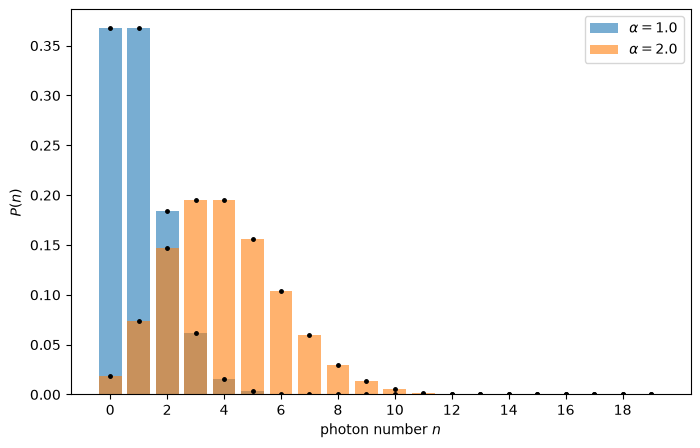

In [7]:
N = 20  # Hilbert space cutoff

# Fock state |n=3>
fock_state = fock(N, 3)

# coherent states
alpha_values = [1.0, 2.0]
coherent_states = [coherent(N, a) for a in alpha_values]

# <n> for each — expect()는 벡터화돼 있어서 리스트 통째로 넘기면 됨
expect_num = expect(num(N), coherent_states)
print("<n>      =", expect_num)
print("|alpha|^2 =", [abs(a)**2 for a in alpha_values])

# P(n) = |<n|alpha>|^2, 상태마다 길이 N짜리 배열
n_array = np.arange(N)
P = [ket2dm(psi).diag().real for psi in coherent_states]

# plot
fig, ax = plt.subplots(figsize=(8, 5))
for a, p in zip(alpha_values, P):
    ax.bar(n_array, p, alpha=0.6, label=rf"$\alpha={a}$")
    ax.plot(n_array, poisson.pmf(n_array, abs(a)**2), "k.", ms=5)  # 해석식 대조
ax.set_xlabel("photon number $n$")
ax.set_ylabel("$P(n)$")
ax.set_xticks(n_array[::2])
ax.legend()

**Expect to see:** For each $\alpha$, a roughly bell-shaped (Poissonian) distribution over $n$,
centered near $n = |\alpha|^2$, with width $\sim \sqrt{|\alpha|^2}$. Larger $\alpha$ gives a wider,
more spread-out distribution further from the origin.

## 2. Rabi Oscillations (Two-Level Atom, Classical Drive)

A two-level atom driven by a classical field, in the rotating frame, has Hamiltonian
$$H = -\tfrac{1}{2}\Delta \sigma_z + \tfrac{1}{2}\Omega \sigma_x$$
where $\Delta$ is detuning and $\Omega$ is the Rabi frequency.

**Task:** Build this Hamiltonian, evolve an initially excited atom ($|e\rangle$) with `sesolve`, and
plot the excited-state population vs time. Try zero detuning and then finite detuning.

In [9]:
sigmax()

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[0. 1.]
 [1. 0.]]

In [10]:
sigmaz()

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 1.  0.]
 [ 0. -1.]]

In [12]:
H

Quantum object: dims=[[2], [2]], shape=(2, 2), type='oper', dtype=CSR, isherm=True
Qobj data =
[[-3.14159265  0.5       ]
 [ 0.5         3.14159265]]

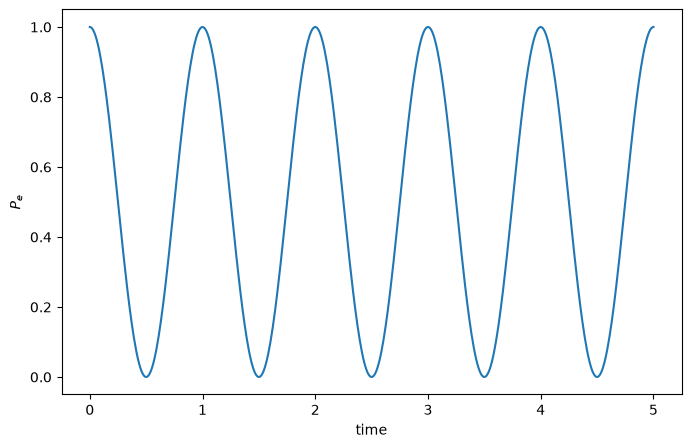

In [17]:
Omega = 1.0 * 2 * np.pi   # Rabi frequency
delta = 0.0                # detuning; try nonzero values too

# TODO: build sigmax(), sigmaz() Hamiltonian H
H = -0.5*delta*sigmaz() + 0.5*Omega*sigmax()
# TODO: initial state: atom in excited state
initial_state = basis(2,0)   # |e>
# TODO: time list, e.g. np.linspace(0, 5, 500)
time_list=np.linspace(0, 5, 500)
# TODO: run sesolve, tracking expectation value of the excited-state projector
result=sesolve(H, initial_state,time_list,e_ops=[ket2dm(basis(2,0))])
# TODO: plot excited-state population vs time
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(time_list, result.expect[0])
ax.set_xlabel("time")
ax.set_ylabel(r"$P_e$")
ax.set_ylim(-0.05, 1.05)
plt.show()

delta/Omega=0  num min=0.000010  analytic min=0.000000  max|num-analytic|=1.47e-05
delta/Omega=1  num min=0.500000  analytic min=0.500000  max|num-analytic|=4.62e-06
delta/Omega=3  num min=0.900000  analytic min=0.900000  max|num-analytic|=4.54e-06


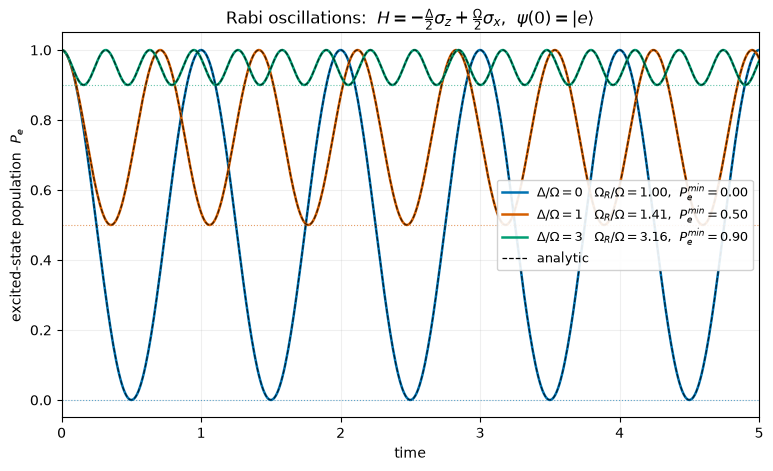

In [19]:
#some answer

Omega = 1.0 * 2 * np.pi          # Rabi frequency (rad/time) -> 주기 1
tlist = np.linspace(0, 5, 500)

psi0   = basis(2, 0)             # |e>  (sigmaz 고유값 +1)
proj_e = ket2dm(basis(2, 0))     # |e><e|

detunings = [0.0, 1.0 * 2*np.pi, 3.0 * 2*np.pi]
colors    = ["#0072B2", "#D55E00", "#009E73"]

fig, ax = plt.subplots(figsize=(9, 5))

for delta, c in zip(detunings, colors):
    H = -0.5 * delta * sigmaz() + 0.5 * Omega * sigmax()
    res = sesolve(H, psi0, tlist, e_ops=[proj_e])

    # 해석해 대조
    Omega_R  = np.sqrt(Omega**2 + delta**2)
    analytic = 1 - (Omega / Omega_R)**2 * np.sin(Omega_R * tlist / 2)**2
    P_min    = delta**2 / Omega_R**2

    ax.plot(tlist, res.expect[0], color=c, lw=1.8,
            label=rf"$\Delta/\Omega={delta/Omega:.0f}$   "
                  rf"$\Omega_R/\Omega={Omega_R/Omega:.2f}$,  $P_e^{{min}}={P_min:.2f}$")
    ax.plot(tlist, analytic, "k--", lw=0.9, alpha=0.7)
    ax.axhline(P_min, color=c, ls=":", lw=0.8, alpha=0.6)

    print(f"delta/Omega={delta/Omega:.0f}  "
          f"num min={res.expect[0].min():.6f}  analytic min={P_min:.6f}  "
          f"max|num-analytic|={np.abs(res.expect[0]-analytic).max():.2e}")

ax.plot([], [], "k--", lw=0.9, label="analytic")
ax.set_xlabel("time")
ax.set_ylabel(r"excited-state population  $P_e$")
ax.set_title(r"Rabi oscillations:  $H=-\frac{\Delta}{2}\sigma_z+\frac{\Omega}{2}\sigma_x$,"
             r"  $\psi(0)=|e\rangle$")
ax.set_xlim(0, 5)
ax.set_ylim(-0.05, 1.05)
ax.legend(loc="center right", fontsize=9, framealpha=0.9)
ax.grid(alpha=0.2)

**Expect to see:** At $\Delta=0$, clean sinusoidal oscillation between $|e\rangle$ and $|g\rangle$
at frequency $\Omega$ (full population transfer). With $\Delta \neq 0$, oscillation is faster
(frequency $\sqrt{\Omega^2+\Delta^2}$) but incomplete — population never fully reaches $|g\rangle$.

## 3. Jaynes-Cummings: Vacuum Rabi Oscillations

Now couple the atom to a *quantized* cavity mode. The Jaynes-Cummings Hamiltonian (rotating frame,
resonance) is
$$H = g\left(a^\dagger \sigma_- + a \sigma_+\right)$$
Excitation swaps back and forth between atom and field at a rate that depends on photon number:
for the field starting in Fock state $|n\rangle$, the atom-cavity swap frequency is $2g\sqrt{n+1}$.

**Task:** Build $H$ using `tensor()` for atom $\otimes$ cavity. Start with atom excited, cavity in
vacuum ($n=0$), evolve, and plot atom excited-state population vs time. Repeat with cavity initially
in Fock states $|1\rangle$ and $|2\rangle$ and compare oscillation frequencies.

In [ ]:
N = 10       # cavity truncation
g = 1.0 * 2 * np.pi

# TODO: define atom and cavity operators via tensor(), e.g.
a = ...   # cavity annihilation operator
sm = ...  # atom lowering operator

# TODO: build H = g * (a.dag()*sm + a*sm.dag())

# TODO: initial states: atom excited, cavity in n=0, then n=1, then n=2 (loop or repeat manually)

# TODO: sesolve for each case, plot atom excited-state population vs time on the same axes,
# label by n


**Expect to see:** For each $n$, clean sinusoidal Rabi oscillation between atom and cavity. Higher
$n$ gives *faster* oscillation, scaling as $\sqrt{n+1}$ (vacuum Rabi splitting generalizes to
$n$-photon vacuum Rabi splitting) — the $n=2$ curve should complete visibly more cycles than $n=0$ in
the same time window.

## 4. Collapse and Revival

Now start the cavity in a **coherent state** instead of a Fock state. Because a coherent state is a
superposition of many photon numbers, and each $n$-component drives Rabi oscillation at its own
frequency $2g\sqrt{n+1}$, the components dephase (collapse) and later rephase (revival) at
$t_{revival} \approx 2\pi\sqrt{\bar n}/g$.

**Task:** Repeat the JC simulation with the cavity in a coherent state with moderate $\bar n$
(e.g. $|\alpha|^2 \sim 4-9$), atom initially excited. Evolve for several revival times and plot atom
inversion vs time.

In [ ]:
N = 30          # need larger cutoff for coherent state + revival dynamics
g = 1.0 * 2 * np.pi
alpha = 2.0     # mean photon number ~ alpha^2

# TODO: build a, sm as in section 3 with the new N

# TODO: initial state: atom excited, cavity in coherent state alpha

# TODO: time list long enough to see collapse AND at least one revival
#   (estimate t_revival ~ 2*pi*sqrt(alpha**2)/g first)

# TODO: sesolve, plot atom excited-state population vs time


**Expect to see:** Fast initial Rabi-like oscillation that visibly damps ("collapses") within a few
$1/g$, a quiet stretch of near-constant population, then oscillation partially reappears
("revives") around your estimated $t_{revival}$ — and imperfectly, with reduced contrast compared to
the initial oscillation.

## 5. Dispersive Regime

When detuning is large compared to the coupling ($\Delta \gg g$, where $\Delta = \omega_{atom} -
\omega_{cavity}$), no real excitation exchange happens; instead the atom's transition frequency is
shifted by an amount proportional to the photon number ("AC Stark"/dispersive shift). To leading order,
$$H_{eff} \approx \chi\, \sigma_z \left(a^\dagger a + \tfrac12\right), \qquad \chi = g^2/\Delta$$
This photon-number-dependent frequency shift is the physical basis of Haroche's QND photon counting.

**Task:** Build the *full* JC Hamiltonian with finite detuning ($H = \Delta \sigma_z /2 + g(a^\dagger
\sigma_- + a\sigma_+)$ in the frame where the cavity is on resonance, atom detuned by $\Delta$).
Prepare the cavity in Fock states $n = 0,1,2,3$ and, for each, numerically extract the atomic
transition frequency (e.g. from the oscillation frequency of $\langle\sigma_x\rangle$ started from a
superposition state, or by diagonalizing $H$ restricted to each excitation-number sector, i.e. $\{|e,n\rangle, |g,n+1\rangle\}$). Compare the
extracted per-photon frequency shift to the analytic $\chi = g^2/\Delta$.

In [ ]:
N = 10
g = 1.0 * 2 * np.pi
Delta = 10.0 * 2 * np.pi   # Delta >> g for dispersive regime
chi_analytic = g**2 / Delta

# TODO: build a, sm, and the full JC Hamiltonian with detuning term (Delta/2)*sigmaz on the atom

# TODO: for n = 0,1,2,3: diagonalize H in that photon-number's 2-level subspace (or use sesolve
#  to track a small oscillation and measure the frequency) and extract the effective qubit
#  frequency shift for that n

# TODO: plot extracted shift vs n and compare against the straight line chi_analytic * n
#  (or chi_analytic * (n + 0.5) depending on your convention)


**Expect to see:** The extracted atomic frequency shift grows linearly with $n$, and the slope
should match $\chi = g^2/\Delta$ to good accuracy (small deviations from higher-order corrections,
growing as $\Delta$ is decreased toward $g$).

## 6. Ramsey Interferometry with Photon-Number-Dependent Phase

This is the actual measurement scheme from the paper: a Ramsey sequence (π/2 – free evolution – π/2)
on the atom, where the free evolution happens under the dispersive Hamiltonian. Because the atom
accumulates a phase $\propto \chi n \, t$ conditioned on the cavity photon number $n$, the final
Ramsey fringe (population vs. free-evolution phase, or vs. detuning of the second pulse) is shifted
depending on $n$ — that shift *is* the photon-number readout.

**Task:** With the cavity in a definite Fock state $|n\rangle$, apply a π/2 pulse to the atom
(instantaneous, e.g. via a rotation operator, not full time evolution), evolve freely under
$H_{eff} = \chi \sigma_z (a^\dagger a + 1/2)$ for a fixed time, apply a second π/2 pulse with variable
phase $\phi$, and compute the final excited-state population vs $\phi$. Repeat for a couple of values
of $n$ and overlay the fringes.

In [ ]:
N = 10
chi = 0.1 * 2 * np.pi
free_evolution_time = 5.0

# TODO: define the pi/2 pulse as a unitary rotation on the atom qubit (e.g. via qutip's rotation
#  functions, or by hand using sigmax/sigmay)

# TODO: for a chosen n, build initial state |n> (x) |g>, apply pi/2 pulse,
#  evolve under H_eff = chi * sigmaz (x) (a.dag()*a + 0.5) for free_evolution_time,
#  then apply second pi/2 pulse with phase phi (sweep phi over e.g. np.linspace(0, 4*pi, 200))
#  and record excited-state population for each phi

# TODO: repeat for a second n value

# TODO: plot both fringes (population vs phi) on the same axes


**Expect to see:** Two sinusoidal Ramsey fringes vs $\phi$ with the *same* period but shifted
relative to each other — the phase offset between the $n$-curves should scale with $\chi n \,
t_{free}$, matching the reasoning above. This phase shift is exactly what lets the atom "read out"
the cavity photon number without absorbing a photon.

## 7. Wigner Functions

The Wigner function is a quasi-probability distribution over phase space $(x,p)$ that fully represents
a quantum state. Coherent states look like displaced Gaussians; Fock states have characteristic rings;
cat states (superpositions of two coherent states) show negative-valued interference fringes between
the two lobes — the hallmark of "non-classicality" that Haroche's group directly measured.

**Task:** Compute and plot `wigner()` for a coherent state, a Fock state, and a Schrödinger cat state
(equal superposition of two coherent states with opposite phase). Use `contourf` or `pcolormesh` over
an $(x,p)$ grid.

In [ ]:
N = 20
xvec = np.linspace(-6, 6, 200)

# TODO: build a coherent state, a Fock state (e.g. n=3), and a cat state
#  cat = (coherent(N, alpha) + coherent(N, -alpha)).unit()

# TODO: compute W = wigner(state, xvec, xvec) for each

# TODO: plot each as a 2D contour/heatmap, one subplot per state, with a shared colorbar
#  (use a diverging colormap centered at 0, e.g. cmap='RdBu_r', since W can be negative)


**Expect to see:** The coherent state is a single circular Gaussian blob offset from the origin.
The Fock state is a ring-shaped (donut) distribution. The cat state shows two Gaussian blobs (one per
coherent-state component) *plus* an oscillatory fringe pattern between them with visibly negative
regions — negativity is impossible for any classical probability distribution.

## 8. Quantum Jumps: `mcsolve` vs `mesolve`

Add cavity photon loss via a single collapse operator $c = \sqrt{\kappa}\, a$. `mesolve` propagates
the *ensemble-averaged* density matrix (smooth decay). `mcsolve` simulates individual stochastic
quantum trajectories with discrete jumps at random times, whose average over many runs reproduces the
`mesolve` result. Watching single trajectories vs the ensemble average is the most direct way to see
"quantum jumps" — the physical process (photon loss events) that Haroche's group video-recorded live.

**Task:** Start the cavity in a Fock state (e.g. $n=5$), no atom needed. Define `c_ops = [sqrt(kappa)
* a]`. Run `mesolve` for $\langle n \rangle(t)$, and separately run `mcsolve` with `ntraj` set small
(e.g. 1-5) and plot individual trajectories of $n(t)$ alongside the `mesolve` ensemble curve.

In [ ]:
N = 15
kappa = 0.3

# TODO: build a = destroy(N); initial state = fock(N, 5); c_ops = [sqrt(kappa) * a]

# TODO: time list

# TODO: run mesolve tracking expect(a.dag()*a, ...) -> smooth ensemble decay curve

# TODO: run mcsolve with ntraj = a small number (e.g. 3), tracking the same observable per
#  trajectory (check how your QuTiP version returns per-trajectory expectation values,
#  e.g. result.expect vs result.runs_expect)

# TODO: plot the individual mcsolve trajectories (thin lines) together with the mesolve
#  ensemble average (thick line) on the same axes


**Expect to see:** Each individual `mcsolve` trajectory looks like a staircase — flat stretches of
constant (integer) photon number punctuated by sudden downward jumps at random times ($n=5\to4\to3\to
\dots$). The `mesolve` curve is a smooth exponential-looking decay of $\langle n\rangle$, and it should
look roughly like the average of many jump trajectories (even 3-5 trajectories will hint at this if
you eyeball where they sit relative to the smooth curve).

## Next Steps

With these tools in hand — JC dynamics, dispersive coupling, Ramsey sequences, Wigner functions, and
quantum trajectories — you have what you need to start reconstructing the QND photon-counting
experiment from Gleyzes et al. (2007). Good luck!